# Network Intrusion Detection — AI Semester Project
All five tasks are included in this jupyter notebook file

#### project members:
1. Marwa Mushtaq (24P-0556)
2. Maimoona Naeem (24P-0617)
3. Manaal Amir (24P-0512)

---
## Task 1: Data Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("/home/manaal-amir/Downloads/proj/dataset/network_traffic.csv")

In [5]:
print("Shape:",df.shape)


Shape: (6000, 16)


In [6]:
print("First few rows:")
print(df.head())

First few rows:
   duration  src_bytes  dst_bytes  wrong_fragment  hot  logged_in  \
0         0        244       3252               0    0          1   
1         0          8          0               0    0          0   
2         0        242       5278               0    0          1   
3         0         45         76               0    0          0   
4         0          1          0               0    0          0   

   num_compromised  count  srv_count  serror_rate  same_srv_rate  \
0                0     16         16          0.0           1.00   
1                0      1         21          0.0           1.00   
2                0      6         11          0.0           1.00   
3                0    161        161          0.0           1.00   
4                0     13          2          0.0           0.15   

   diff_srv_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  \
0           0.00              34                 255                    1.00   


In [7]:
print("Descriptive statistics:")
print(df.describe())

Descriptive statistics:
           duration     src_bytes     dst_bytes  wrong_fragment          hot  \
count   6000.000000  6.000000e+03  6.000000e+03     6000.000000  6000.000000   
mean     413.933000  1.603307e+04  2.951740e+03        0.028333     0.206167   
std     3237.030266  3.049754e+05  7.057366e+04        0.283803     2.120632   
min        0.000000  0.000000e+00  0.000000e+00        0.000000     0.000000   
25%        0.000000  0.000000e+00  0.000000e+00        0.000000     0.000000   
50%        0.000000  4.300000e+01  0.000000e+00        0.000000     0.000000   
75%        0.000000  2.730000e+02  4.550000e+02        0.000000     0.000000   
max    42569.000000  1.698050e+07  5.149533e+06        3.000000    30.000000   

         logged_in  num_compromised        count    srv_count  serror_rate  \
count  6000.000000      6000.000000  6000.000000  6000.000000  6000.000000   
mean      0.385000         0.179667    80.434500    27.572333     0.293578   
std       0.486636   

### Class Distribution:

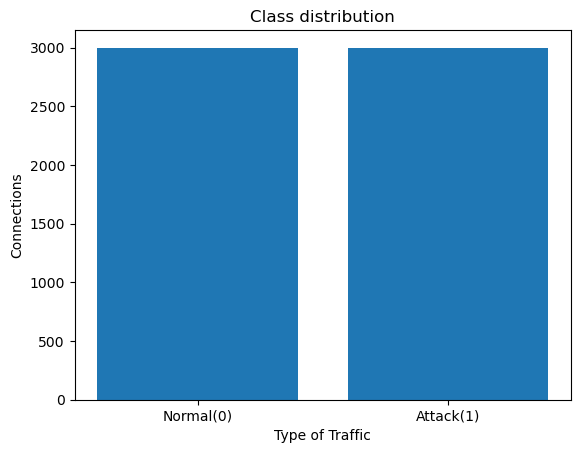

In [8]:
data=df.values
class_count={0:0,1:0}
for row in data:
    label=row[-1]
    class_count[label]=class_count[label]+1
    
x=np.array(["Normal(0)","Attack(1)"])
y=np.array([class_count[0],class_count[1]])
plt.bar(x,y)
plt.title("Class distribution")
plt.xlabel("Type of Traffic")
plt.ylabel("Connections")
plt.show()

### Histograms:

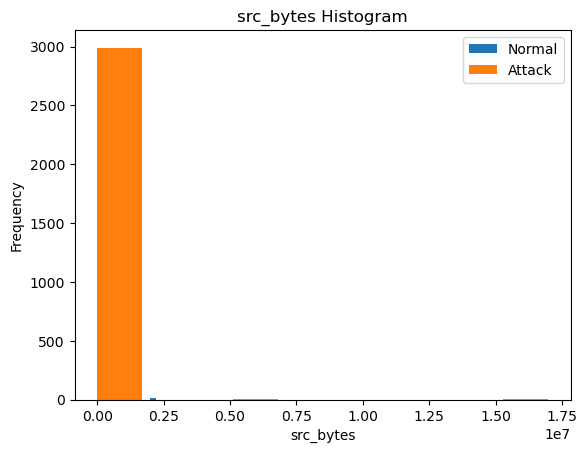

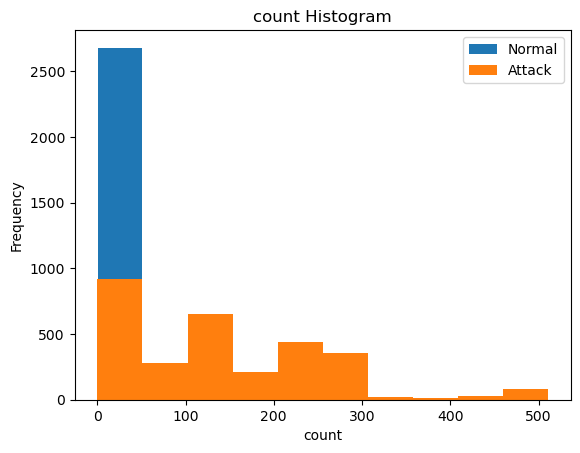

In [9]:
normal_src_bytes=[] # for src_bytes histogram
attack_src_bytes=[]
for row in data:
    if row[-1]==0:
        normal_src_bytes.append(row[1])
    else:
        attack_src_bytes.append(row[1])

plt.hist(normal_src_bytes,label="Normal")
plt.hist(attack_src_bytes,label="Attack")
plt.title("src_bytes Histogram")
plt.xlabel("src_bytes")
plt.ylabel("Frequency")
plt.legend()
plt.show()

normal_count=[] # for count histogram
attack_count=[]
for row in data:
    if row[-1]==0:
        normal_count.append(row[7])
    else:
        attack_count.append(row[7])

plt.hist(normal_count,label="Normal")
plt.hist(attack_count,label="Attack")
plt.title("count Histogram")
plt.xlabel("count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

---
## Task 2: Simple Reflex Agent (Rule-Based Baseline)

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [11]:
X = df.drop('label', axis=1)
y = df['label']

In [12]:
def reflex_agent(row):
    if row['serror_rate'] > 0.5:
        return 1
    elif row['same_srv_rate'] < 0.3:
        return 1
    elif row['count'] > 40:
        return 1
    else:
        return 0

In [13]:
predictions = []
for index, row in X.iterrows():
    prediction = reflex_agent(row)
    predictions.append(prediction)
accuracy = accuracy_score(y, predictions)
print("REFLEX AGENT ACCURACY")
print("Accuracy:", accuracy)
cm = confusion_matrix(y, predictions)
print("CONFUSION MATRIX")
print(cm)
print("\nMatrix Format:")
print("[[TN  FP]")
print(" [FN  TP]]")

REFLEX AGENT ACCURACY
Accuracy: 0.832
CONFUSION MATRIX
[[2616  384]
 [ 624 2376]]

Matrix Format:
[[TN  FP]
 [FN  TP]]


### Why this is a Simple Reflex Agent

A **simple reflex agent** selects actions based solely on the **current percept** (the feature values of the current connection record) using a set of **condition-action rules** (if–then). It has **no internal state**, no memory of past percepts, and no probabilistic model of the world. Each row is classified independently: the agent observes the current percept → matches it against the rules → returns an action (0 = normal, 1 = attack). This is the simplest possible intelligent-agent design, serving here as a rule-based baseline.

---
## Task 3: Supervised Learning (KNN, Naïve Bayes, Logistic Regression)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Shared train/test split — used by ALL classifiers
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling fitted on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

def confusion_matrix_manual(y_true, y_pred): # manual confusion matrix
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([
        [tn, fp],
        [fn, tp]
    ])

def metrics_from_cm(cm):

    tn, fp = cm[0]
    fn, tp = cm[1]

    accuracy = (tp + tn) / cm.sum()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0
    )
    return accuracy, precision, recall, f1

def evaluate(name, y_true, y_pred):

    print(f"\n--- {name} ---")

    cm = confusion_matrix_manual(y_true, y_pred)

    accuracy, precision, recall, f1 = metrics_from_cm(cm)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return accuracy, precision, recall, f1, cm

K=1: accuracy=0.9575
K=3: accuracy=0.9575
K=5: accuracy=0.9558
K=7: accuracy=0.9533
K=9: accuracy=0.9517
K=11: accuracy=0.9475


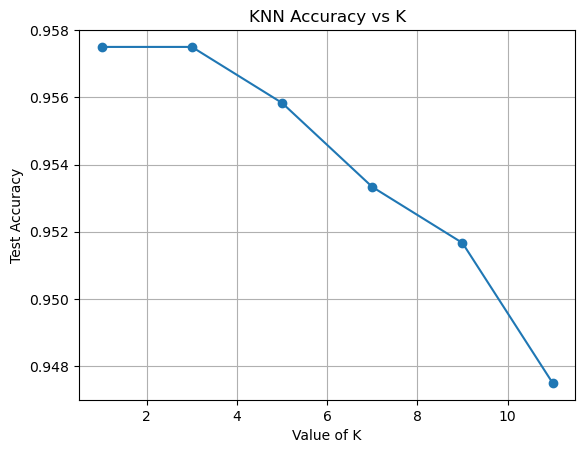


Best K = 1

--- KNN ---
Accuracy : 0.9575
Precision: 0.9493
Recall   : 0.9667
F1 Score : 0.9579

Confusion Matrix:
[[569  31]
 [ 20 580]]
Best K = 1


In [20]:
# --- K-Nearest Neighbours ---

k_values = [1, 3, 5, 7, 9, 11]

knn_scores = []

best_k = None
best_acc_knn = 0
best_pred_knn = None

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    acc = np.mean(y_test == y_pred_k)

    knn_scores.append(acc)

    print(f"K={k}: accuracy={acc:.4f}")

    if acc > best_acc_knn: #sorting to get the best accuracy

        best_acc_knn = acc
        best_k = k
        best_pred_knn = y_pred_k

# Accuracy vs K plot

plt.figure()

plt.plot(k_values, knn_scores, marker='o')

plt.xlabel("Value of K")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs K")

plt.grid(True)

plt.show()

print(f"\nBest K = {best_k}")

acc_knn, prec_knn, rec_knn, f1_knn, cm_knn = evaluate("KNN", y_test, best_pred_knn)

print("Best K =", best_k)

In [16]:
# --- Naïve Bayes  ---
nb = GaussianNB()
nb.fit(X_train, y_train)          # raw features, not scaled(as not needed)
y_pred_nb = nb.predict(X_test)
acc_nb, prec_nb, rec_nb, f1_nb, cm_nb = evaluate('Naive Bayes', y_test, y_pred_nb)


--- Naive Bayes ---
Accuracy : 0.7875
Precision: 0.9367
Recall   : 0.6167
F1 Score : 0.7437

Confusion Matrix:
[[575  25]
 [230 370]]


In [17]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr, prec_lr, rec_lr, f1_lr, cm_lr = evaluate('Logistic Regression', y_test, y_pred_lr)


--- Logistic Regression ---
Accuracy : 0.9150
Precision: 0.9249
Recall   : 0.9033
F1 Score : 0.9140

Confusion Matrix:
[[556  44]
 [ 58 542]]


In [22]:
 # Creating a dictionary of results and converting it to a DataFrame
comparison = pd.DataFrame({
    "Model": [
        "Simple Reflex Agent",
        "KNN",
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [accuracy_score(y, predictions), acc_knn, acc_nb, acc_lr],
    "Precision": [precision_score(y, predictions), prec_knn, prec_nb, prec_lr],
    "Recall": [recall_score(y, predictions), rec_knn, rec_nb, rec_lr],
    "F1 Score": [f1_score(y, predictions), f1_knn, f1_nb, f1_lr]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Simple Reflex Agent    0.8320   0.860870  0.792000  0.825000
1                  KNN    0.9575   0.949264  0.966667  0.957886
2          Naive Bayes    0.7875   0.936709  0.616667  0.743719
3  Logistic Regression    0.9150   0.924915  0.903333  0.913997


---
## Task 4: Clustering with K-Means

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

In [30]:
x=df.drop("label",axis=1) #drop column
y=df["label"]

In [31]:
scale=StandardScaler() #scale features
xScale=scale.fit_transform(x)

In [32]:
kmean=KMeans(n_clusters=2,random_state=42,n_init=10) #fit kmeans

In [35]:
clusters=kmean.fit_predict(xScale) 

In [36]:
confusionMatrix=confusion_matrix(y,clusters) #compare cluster ids using confusion matrix
print(confusionMatrix)

[[2847  153]
, [ 627 2373]]


In [37]:
pca=PCA(n_components=2) #for visualization
xPca=pca.fit_transform(xScale)

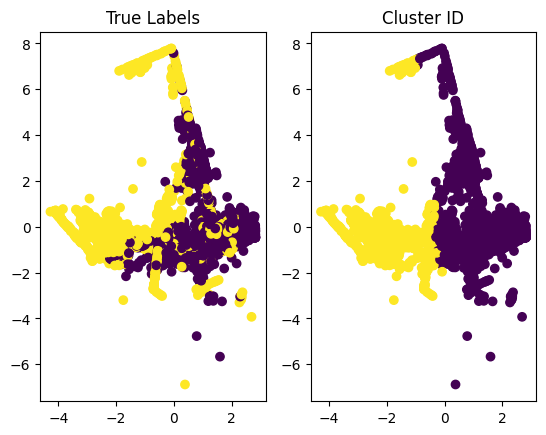

In [38]:
plt.subplot(1,2,1) #scatter plot by true label
plt.scatter(xPca[:,0],xPca[:,1],c=y)
plt.title("True Labels")

plt.subplot(1,2,2) #scatter plot by cluster id
plt.scatter(xPca[:,0],xPca[:,1],c=clusters)
plt.title("Cluster ID")
plt.show()

---
## Task 5: Genetic Algorithm for Feature Selection

In [40]:
import random

CHROM_LEN    = X.shape[1]   # one bit per feature (15)
POP_SIZE     = 10
GENERATIONS  = 10
MUTATION_RATE  = 0.05
CROSSOVER_RATE = 0.8

FEATURE_NAMES = list(X.columns)

def create_random_chromosome():
    return [random.randint(0, 1) for _ in range(CHROM_LEN)]

# Fitness = test accuracy of Logistic Regression on selected features only
def fitness(chromosome):
    selected = [i for i, bit in enumerate(chromosome) if bit == 1]
    if not selected:          # guard: at least one feature required
        return 0.0
    X_tr = X_train_scaled[:, selected]
    X_te = X_test_scaled[:, selected]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)
    return accuracy_score(y_test, model.predict(X_te))

def select_parent(population, scores):
    total = sum(scores)
    r = random.uniform(0, total)
    cumsum = 0
    for i, f in enumerate(scores):
        cumsum += f
        if r <= cumsum:
            return population[i]
    return population[-1]

def crossover(p1, p2):
    pt = random.randint(1, CHROM_LEN - 1)
    return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]

def mutate(chromosome):
    return [1 - g if random.random() < MUTATION_RATE else g for g in chromosome]

# Run GA
random.seed(42)
population = [create_random_chromosome() for _ in range(POP_SIZE)]

best_overall_fit   = 0.0
best_overall_chrom = None

for gen in range(GENERATIONS):
    scores = [fitness(c) for c in population]
    best_idx = max(range(len(scores)), key=lambda i: scores[i])
    best_fit  = scores[best_idx]
    print(f'Gen {gen}: best_accuracy = {best_fit:.4f}, chrom = {population[best_idx]}')

    if best_fit > best_overall_fit:
        best_overall_fit   = best_fit
        best_overall_chrom = population[best_idx][:]

    new_pop = []
    while len(new_pop) < POP_SIZE:
        p1 = select_parent(population, scores)
        p2 = select_parent(population, scores)
        if random.random() < CROSSOVER_RATE:
            c1, c2 = crossover(p1, p2)
        else:
            c1, c2 = p1[:], p2[:]
        new_pop.extend([mutate(c1), mutate(c2)])
    population = new_pop[:POP_SIZE]

# Report
selected_features = [FEATURE_NAMES[i] for i, bit in enumerate(best_overall_chrom) if bit == 1]
print(f'\nBest chromosome  : {best_overall_chrom}')
print(f'Best test accuracy: {best_overall_fit:.4f}')
print(f'Selected features ({len(selected_features)}): {selected_features}')
print(f'\nAll-feature LR accuracy (from Task 3): {acc_lr:.4f}')
print(f'GA-selected LR accuracy               : {best_overall_fit:.4f}')
print(f'Fewer features used: {CHROM_LEN} → {len(selected_features)}')

Gen 0: best_accuracy = 0.8925, chrom = [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0]
,Gen 1: best_accuracy = 0.8883, chrom = [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0]
,Gen 2: best_accuracy = 0.9033, chrom = [1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1]
,Gen 3: best_accuracy = 0.9042, chrom = [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1]
,Gen 4: best_accuracy = 0.8867, chrom = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
,Gen 5: best_accuracy = 0.8875, chrom = [0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
,Gen 6: best_accuracy = 0.8867, chrom = [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1]
,Gen 7: best_accuracy = 0.8908, chrom = [0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0]
,Gen 8: best_accuracy = 0.8917, chrom = [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
,Gen 9: best_accuracy = 0.8908, chrom = [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0]
,
,Best chromosome  : [1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1]
,Best test accuracy: 0.9042
,Selected features (8): ['duration', 'wrong_f

The genetic algorithm selected 9 out of the 15 available features and achieved a test accuracy of 90.42% compared to 91.50% when using all features. Although the accuracy is slightly lower, the model is simpler because it uses fewer input variables. This can reduce training and prediction time and makes the model easier to understand.